In [1]:
# Import necessary resources
import os
import sys
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# %matplotlib inline
plt.rcParams['figure.figsize'] = [14, 14]

sys.path.append(os.path.abspath("src"))
from models import MLP
from utils import first_order_loss_with_ic, second_order_loss_with_ic, second_order_pde_loss_with_bc

# First-Order ODEs

The first two examples are First-Order ODEs. Note that a first-order ODE must be able to be written in the form 

\begin{align}
\frac{d}{dx}\Psi + p(x)\Psi = g(x)
\end{align}

Where both $p(x)$ and $g(x)$ are continuous functions.

## Example I
Consider the first-order ODE:
\begin{align}
\frac{d}{dx}\Psi + (x+\frac{1 + 3 x^2}{1 + x+ x^3})\Psi = x^3 + 2x +x^2\frac{1 + 3x^2}{1 + x + x^3},\quad \Psi(0) = 1 \quad and \quad x\in [0,1]
\end{align}
Solve for $\Psi(x)$

### Step 1: Define DE and Initial Condition

In [2]:
# Define Differential Equation
# Initial condition
f_0 = 1

# differential equation
def g(x):
    return x**3 + 2*x + (x**2)*((1+3*x**2)/(1+x+x**3))

def p(x):
    return x + ((1+3*(x**2))/(1+x+x**3))

### Step 2: Train the NN

In [3]:
learning_rate = 0.0005
epochs = 10000
display_step = 100

# Define NN
N = MLP()

# Create optimizer
optimizer = optim.Adam(N.parameters(), lr=learning_rate)

# Run the training steps
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = first_order_loss_with_ic(N, p, g, f_0)
    
    # Backpropagate
    loss.backward()
    
    # Adjust model parameters accordingly
    optimizer.step()
    
    if epoch % display_step == 0:
        print("epoch: {}, loss: {}".format(epoch, loss.item()))

epoch: 0, loss: 10.00789737701416
epoch: 100, loss: 2.1319820880889893
epoch: 200, loss: 0.318816602230072
epoch: 300, loss: 0.02175910584628582
epoch: 400, loss: 0.005578313022851944
epoch: 500, loss: 0.006284988950937986
epoch: 600, loss: 0.005777040496468544
epoch: 700, loss: 0.005760714877396822
epoch: 800, loss: 0.00541064515709877
epoch: 900, loss: 0.004478405229747295
epoch: 1000, loss: 0.004688100423663855
epoch: 1100, loss: 0.005016304552555084
epoch: 1200, loss: 0.004841959103941917
epoch: 1300, loss: 0.0037740275729447603
epoch: 1400, loss: 0.00392161775380373
epoch: 1500, loss: 0.005156305618584156
epoch: 1600, loss: 0.004997019190341234
epoch: 1700, loss: 0.005030065309256315
epoch: 1800, loss: 0.004567894618958235
epoch: 1900, loss: 0.004413457587361336
epoch: 2000, loss: 0.004500747192651033
epoch: 2100, loss: 0.004739050753414631
epoch: 2200, loss: 0.005413656588643789
epoch: 2300, loss: 0.004837287589907646
epoch: 2400, loss: 0.004271612502634525
epoch: 2500, loss: 0.0

### Step 3: Visualize Result

Solving the DE by hand gives the exact result of $\Psi_a(x) = \frac{e^{\frac{-x^2}{2}}}{1+x+x^3} + x^2$. We will plot this against the trained trial solution.

Text(0, 0.5, 'Error')

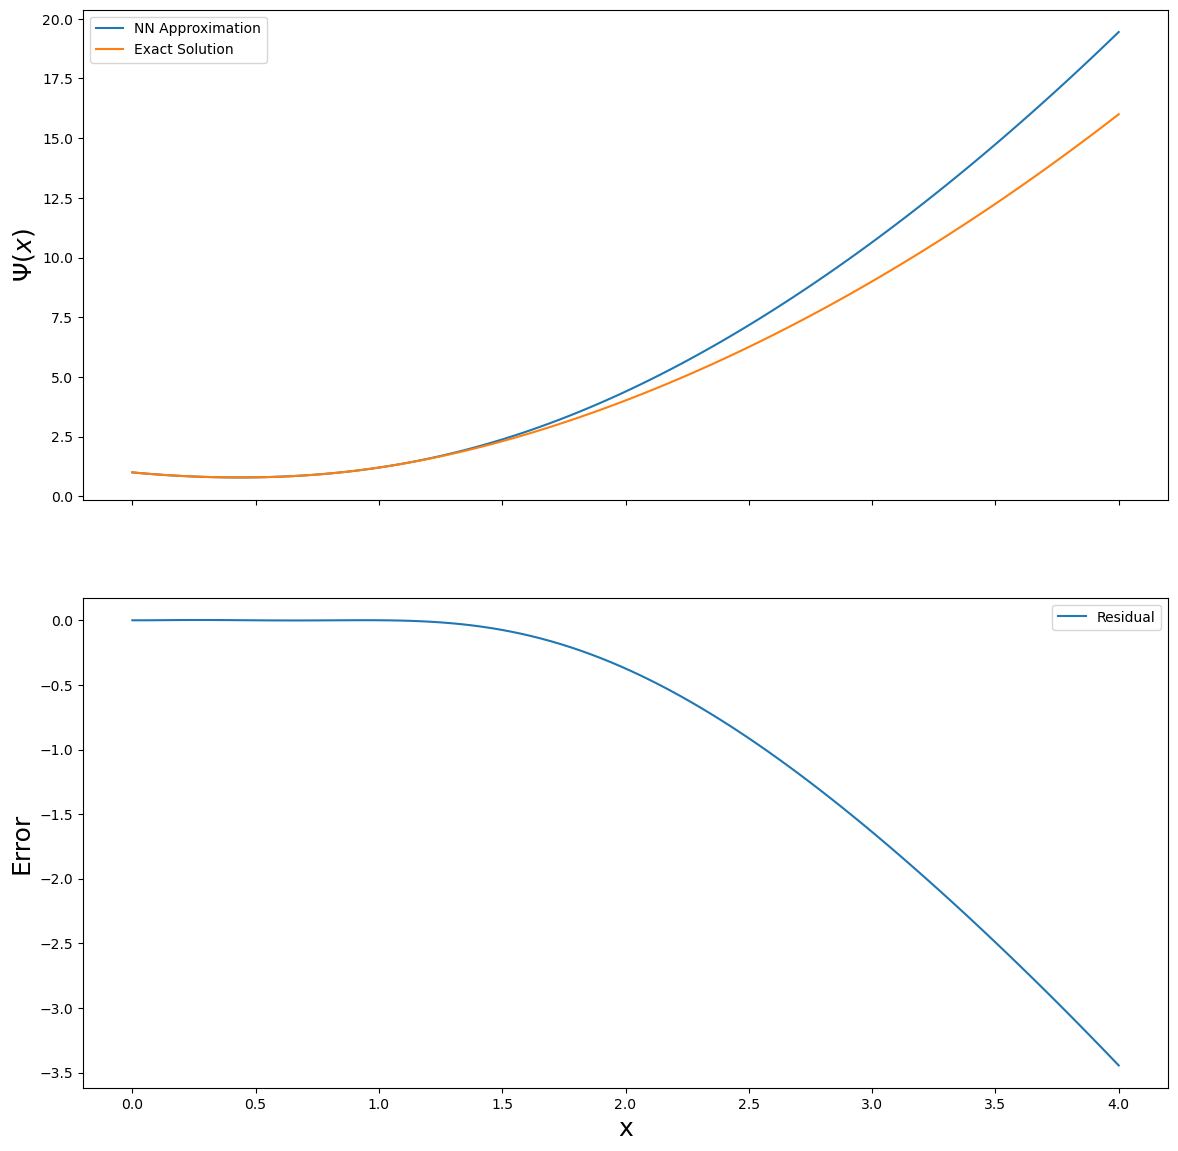

In [4]:
# Calculate 
x = torch.linspace(0, 4, 100, requires_grad=True).unsqueeze(1)
y_approx = (f_0 + x * N(x)).squeeze(0).detach().numpy().transpose()[0]
y_exact = ((torch.exp(-(x**2)/2)/(1+x+x**3))+x**2).squeeze(0).detach().numpy().transpose()[0]
x = x.squeeze(0).detach().numpy().transpose()[0]


fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
# Plot the analytical solution with the approximation
ax1.plot(x, y_approx, label='NN Approximation')
ax1.plot(x, y_exact, label='Exact Solution')
ax1.legend()

# Plot the residual
ax2.plot(x, y_exact-y_approx, label='Residual')
ax2.legend()

ax2.set_xlabel('x', fontsize=18)
ax1.set_ylabel("$\Psi(x)$", fontsize=18)
ax2.set_ylabel("Error", fontsize=18)

## Example II: More Complicated
Consider the first-order ODE:
\begin{align}
\frac{d}{dx}\Psi + \frac{1}{5}\Psi = e^{-\frac{x}{5}}cos(x),\quad \Psi(0) = 0 \quad and \quad x\in [0,10]
\end{align}
Solve for $\Psi(x)$

### Step 1: Define DE and Initial Condition

In [5]:
# Define sample problem
# Initial condition
f_0 = 0

# differential equation
def g(x):
    return torch.exp(-x/5)*torch.cos(x)

def p(x):
    return 1/5

### Step 2: Train the NN

In [6]:
learning_rate = 0.05
epochs = 5000
display_step = 500

# Define NN
N = MLP()

# Create optimizer
optimizer = optim.Adam(N.parameters(), lr=learning_rate)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = first_order_loss_with_ic(N, p, g, f_0, 0, 6, 20)
    loss.backward()
    optimizer.step()
    # print(loss.item())
    if epoch % display_step == 0:
        print("epoch: {}, loss: {}".format(epoch, loss.item()))

epoch: 0, loss: 86.86449432373047
epoch: 500, loss: 0.034808818250894547
epoch: 1000, loss: 0.02317914366722107
epoch: 1500, loss: 0.02572852186858654
epoch: 2000, loss: 0.027743253856897354
epoch: 2500, loss: 0.010061905719339848
epoch: 3000, loss: 0.03985556960105896
epoch: 3500, loss: 0.005648625083267689
epoch: 4000, loss: 0.005516204982995987
epoch: 4500, loss: 0.008858324028551579


### Step 3: Visualize Result

Solving the DE by hand gives the exact result of $\Psi_a(x) = e^{-\frac{x}{5}}sin(x)$. We will plot this against the trained trial solution.

Text(0, 0.5, 'Error')

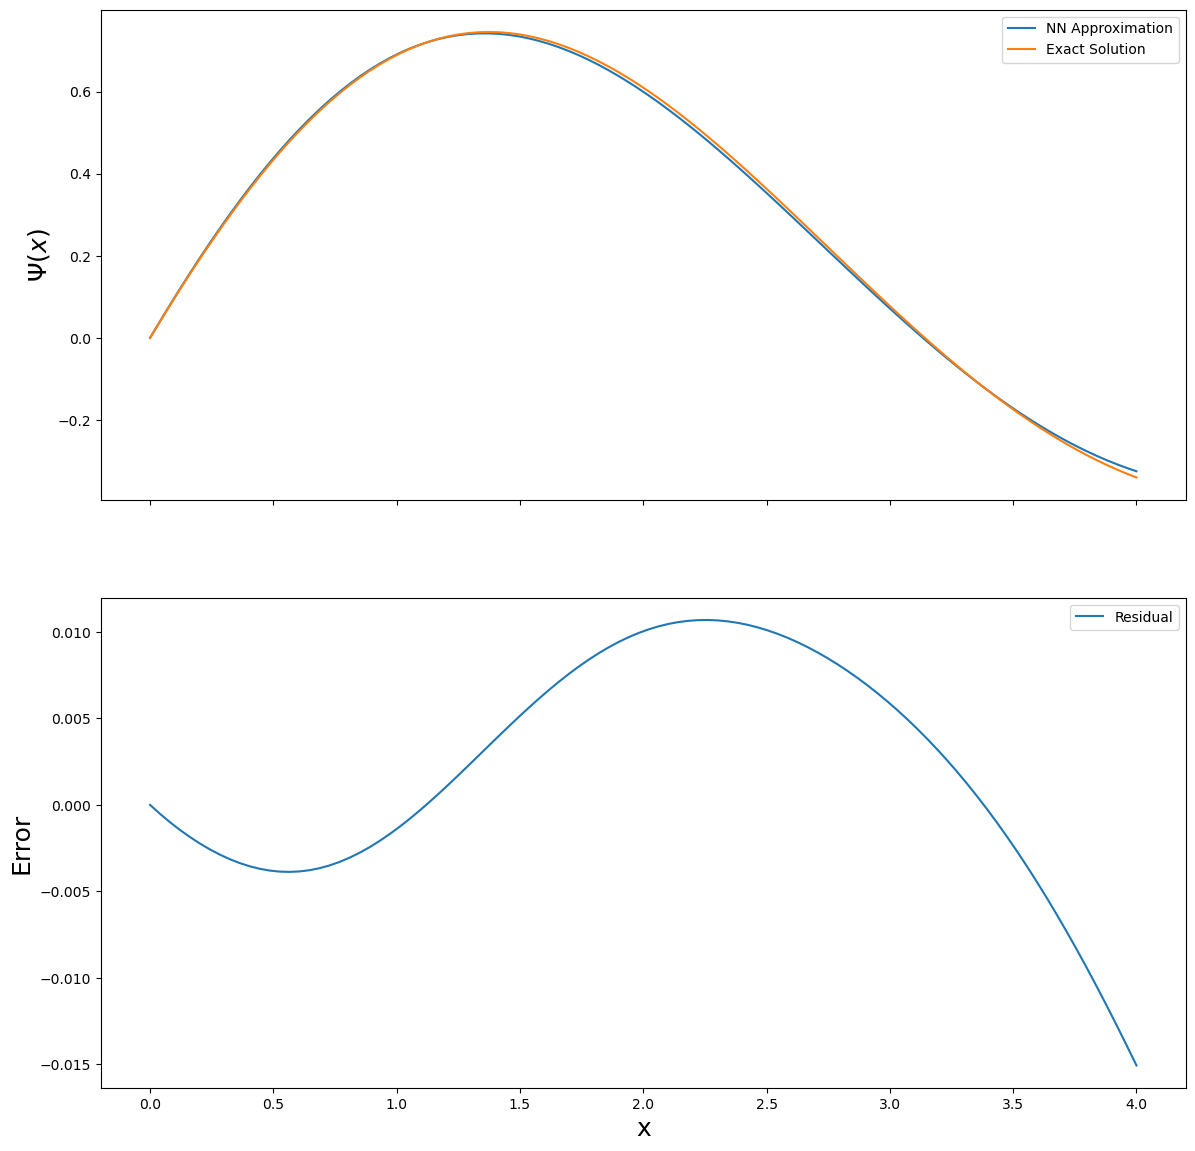

In [7]:
x = torch.linspace(0, 4, 100, requires_grad=True).unsqueeze(1)
y_approx = (f_0 + x * N(x)).squeeze(0).detach().numpy().transpose()[0]
y_exact = (torch.exp(-x/5)*torch.sin(x)).squeeze(0).detach().numpy().transpose()[0]
x = x.squeeze(0).detach().numpy().transpose()[0]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(x, y_approx, label='NN Approximation')
ax1.plot(x, y_exact, label='Exact Solution')
ax1.legend()
ax2.plot(x, y_exact-y_approx, label='Residual')
ax2.legend()

ax2.set_xlabel('x', fontsize=18)
ax1.set_ylabel("$\Psi(x)$", fontsize=18)
ax2.set_ylabel("Error", fontsize=18)

# Second-Order ODEs

Note that a second-order ODE must be able to be written in the form 

\begin{align}
\frac{d^2}{dx^2}\Psi + a(x)\frac{d}{dx}\Psi + b(x)\Psi = g(x)
\end{align}

Where $a(x)$, $b(x)$, and $g(x)$ are continuous functions.

## Example III
The method described will be used to approximate the solution $\Psi(x)$ to the following second-order ODE:

\begin{align}
\frac{d^2}{dx^2}\Psi + \frac{1}{5}\frac{d}{dx}\Psi + \Psi= -\frac{1}{5}e^{-\frac{x}{5}}cos(x), \quad \Psi(0) = 0, \; \frac{d}{dx}\Psi(0)=1 \quad over \quad x\in [0,2]
\end{align}

In [8]:
# Define sample problem
# Initial condition
f_0 = 0
f_prime_0 = 1

# differential equation
def g(x):
    result = -(1.0/5.0)*torch.ones_like(x, requires_grad=True)*torch.exp(-x/5.0)*torch.cos(x)
#     print(result.requires_grad)
    return result

def a(x):
    result =(1.0/5.0)*torch.ones_like(x, requires_grad=True)
#     print(result.requires_grad)
    return result

def b(x):
    return torch.ones_like(x, requires_grad=True)

domain = (0, 2)

In [9]:
learning_rate = 0.0007
epochs = 5000
display_step = 100

# Define NN
N = MLP(n=32)

# Create optimizer
optimizer = optim.Adam(N.parameters(), lr=learning_rate)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = second_order_loss_with_ic(N, a, b, g, f_0, f_prime_0, domain[0], domain[1], 9)
    loss.backward()
    optimizer.step()
    
    if epoch % display_step == 0:
        print("epoch: {}, loss: {}".format(epoch, loss.item()))

epoch: 0, loss: 59.02661895751953
epoch: 100, loss: 0.9371313452720642
epoch: 200, loss: 0.2949310541152954
epoch: 300, loss: 0.29983994364738464
epoch: 400, loss: 0.25410163402557373
epoch: 500, loss: 0.8468712568283081
epoch: 600, loss: 0.5668638348579407
epoch: 700, loss: 1.465414047241211
epoch: 800, loss: 2.2516613006591797
epoch: 900, loss: 0.04272918775677681
epoch: 1000, loss: 1.1087770462036133
epoch: 1100, loss: 0.4659995138645172
epoch: 1200, loss: 0.287722110748291
epoch: 1300, loss: 0.14097848534584045
epoch: 1400, loss: 0.4546336829662323
epoch: 1500, loss: 0.668906033039093
epoch: 1600, loss: 0.38489753007888794
epoch: 1700, loss: 0.12683096528053284
epoch: 1800, loss: 0.876755952835083
epoch: 1900, loss: 0.1403757631778717
epoch: 2000, loss: 0.28691214323043823
epoch: 2100, loss: 0.19079002737998962
epoch: 2200, loss: 0.6008304357528687
epoch: 2300, loss: 0.5006318688392639
epoch: 2400, loss: 0.7620238065719604
epoch: 2500, loss: 0.23790287971496582
epoch: 2600, loss: 0

Text(0, 0.5, 'Error')

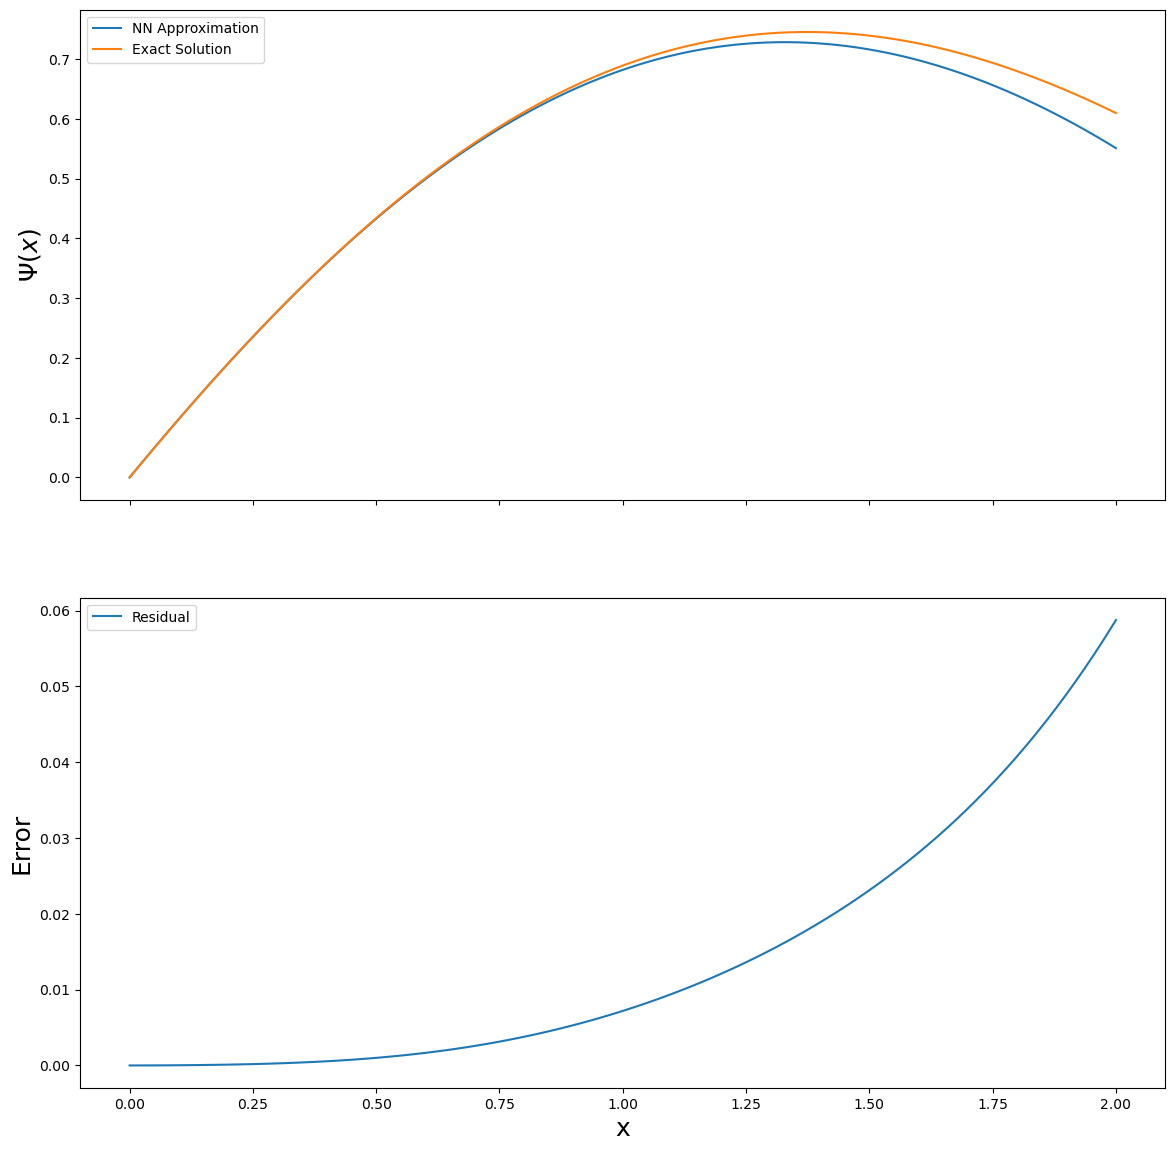

In [10]:
x = torch.linspace(domain[0], domain[1], 100, requires_grad=True).unsqueeze(1)
y_approx = (f_0 + x*f_prime_0 + x**2 * N(x)).squeeze(0).detach().numpy().transpose()[0]
y_exact = (torch.exp(-x/5)*torch.sin(x)).squeeze(0).detach().numpy().transpose()[0]
x = x.squeeze(0).detach().numpy().transpose()[0]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(x, y_approx, label='NN Approximation')
ax1.plot(x, y_exact, label='Exact Solution')
ax1.legend()
ax2.plot(x, y_exact-y_approx, label='Residual')
ax2.legend()

ax2.set_xlabel('x', fontsize=18)
ax1.set_ylabel("$\Psi(x)$", fontsize=18)
ax2.set_ylabel("Error", fontsize=18)

# Poisson equation

## Example V
The method described will be used to approximate the solution $\Psi(x,y)$ to the following second-order PDE:

\begin{align}
\nabla^2 \Psi(x,y) = e^{-x}(x - 2 + y^3 + 6y), 
\quad (x,y) \in [0,1]\times[0,1]
\end{align}
with Dirichlet boundary conditions:

\begin{align}
\Psi(0,y) &= y^3, \\
\Psi(1,y) &= (1+y^3)e^{-1}, \\
\Psi(x,0) &= x(e^{-x}-e^{-1}), \\
\Psi(x,1) &= (1+x)e^{-x} - (1 - x + 2xe^{-1}).
\end{align}

In [11]:
lr = 0.03
epochs = 2000
display_step = 100

# Define NN
N = MLP(dim=2)

# Create optimizer
optimizer = optim.Adam(N.parameters(), lr=lr)

# Run the training steps
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = second_order_pde_loss_with_bc(N)
    
    # Backpropagate
    loss.backward()
    
    # Adjust model parameters accordingly
    optimizer.step()
    
    if epoch % display_step == 0:
        print("epoch: {}, loss: {}".format(epoch, loss.item()))

epoch: 0, loss: 1145.175048828125
epoch: 100, loss: 59.383541107177734
epoch: 200, loss: 51.23772430419922
epoch: 300, loss: 46.51382064819336
epoch: 400, loss: 45.52928161621094
epoch: 500, loss: 44.959285736083984
epoch: 600, loss: 44.70855712890625
epoch: 700, loss: 44.49591827392578
epoch: 800, loss: 44.36247634887695
epoch: 900, loss: 44.208709716796875
epoch: 1000, loss: 44.04021453857422
epoch: 1100, loss: 43.743804931640625
epoch: 1200, loss: 43.44609832763672
epoch: 1300, loss: 42.41682434082031
epoch: 1400, loss: 42.28240966796875
epoch: 1500, loss: 42.249717712402344
epoch: 1600, loss: 42.087974548339844
epoch: 1700, loss: 41.932640075683594
epoch: 1800, loss: 41.77686309814453
epoch: 1900, loss: 41.65628433227539


(100, 100)
tensor(0.)
(100, 100)


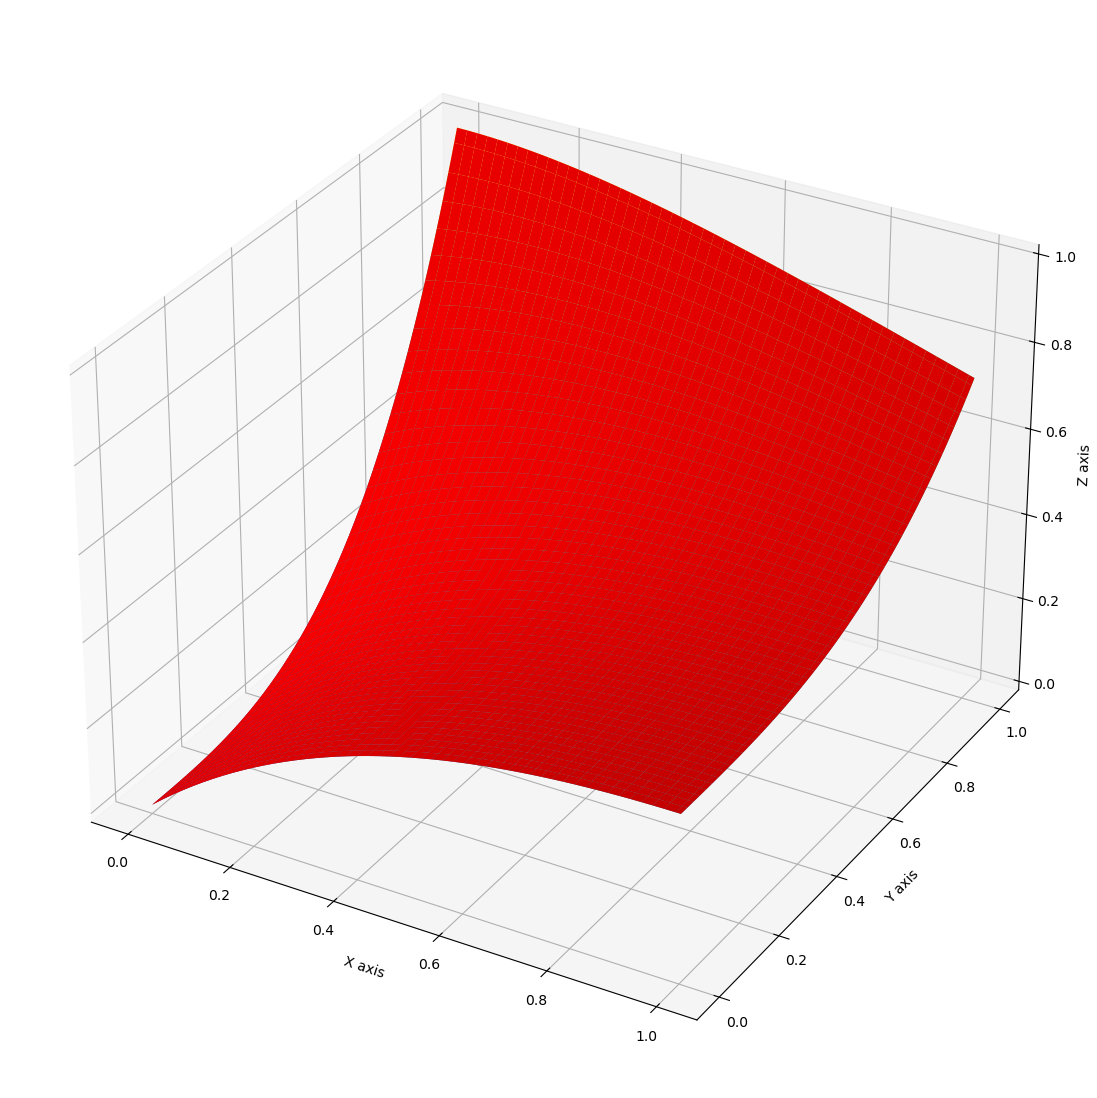

In [12]:
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
x, y = np.meshgrid(x, y)
# print(x, y)

# # Compute z values based on the function z = e^(-x(x + y^3))
z = np.exp(-x)*((x + y**3))
print(z.shape)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x, y, z, cmap='viridis')

xy_pairs = torch.tensor(np.column_stack([x.ravel(), y.ravel()]), dtype = torch.float32)
print((xy_pairs[0][0]))
def trial_solution(inp):
    x = inp[:, 0]
    y = inp[:, 1]
    result = (1-x)*(y**3) + x*(1+y**3)*torch.exp(torch.tensor(-1)) + (1-y)*x*(torch.exp(-x) - torch.exp(torch.tensor(-1))) + y*((1+x)*torch.exp(-x) - (1-x + 2*x*torch.exp(torch.tensor(-1)))) + x*(1-x)*y*(1-y)*(N(x,y).squeeze())
    return result
z_trial = trial_solution(xy_pairs).detach().numpy().reshape(100,100)
print(z_trial.shape)

ax.plot_surface(x, y, z_trial, color='red')
# # Adding labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

## Example VI
The method described will be used to approximate the solution $\Psi(x,y)$ to the following second-order PDE:

\begin{align}
\nabla^2 \Psi(x,y) = (2 - \pi^2 y^2)\sin(\pi x),
\quad (x,y) \in [0,1]\times[0,1]
\end{align}

with mixed boundary conditions:

\begin{align}
\Psi(0,y) = \Psi(1,y) &= \Psi(x,0) = 0 \\
\frac{\partial}{\partial y}\Psi(x,1) &= 2\sin(\pi x)
\end{align}

(100, 100)
tensor(0.)
Maximum abs error: 0.0006978733438671725
(100, 100)


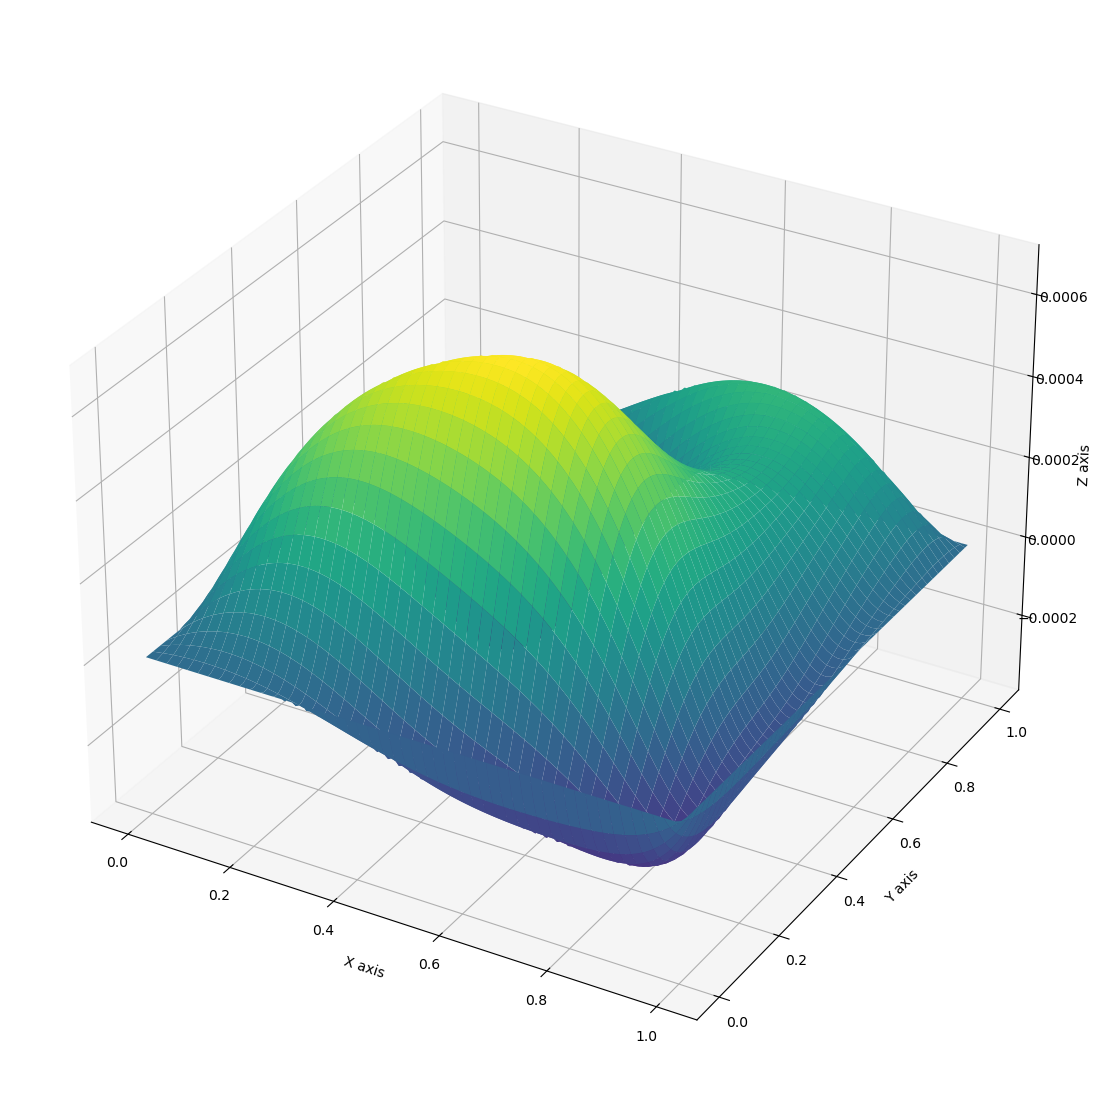

In [13]:
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
x, y = np.meshgrid(x, y)
# print(x, y)

# # Compute z values based on the function z = e^(-x(x + y^3))
z = np.exp(-x)*((x + y**3))
print(z.shape)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xy_pairs = torch.tensor(np.column_stack([x.ravel(), y.ravel()]), dtype = torch.float32)
print((xy_pairs[0][0]))
def trial_solution(inp):
    x = inp[:, 0]
    y = inp[:, 1]
    result = (1-x)*(y**3) + x*(1+y**3)*torch.exp(torch.tensor(-1)) + (1-y)*x*(torch.exp(-x) - torch.exp(torch.tensor(-1))) + y*((1+x)*torch.exp(-x) - (1-x + 2*x*torch.exp(torch.tensor(-1)))) + x*(1-x)*y*(1-y)*(N(x,y).squeeze())
    return result
z_trial = trial_solution(xy_pairs).detach().numpy().reshape(100,100)
print(f"Maximum abs error: {np.max((z_trial-z))}")
print(z_trial.shape)

ax.plot_surface(x, y, (z_trial-z), cmap='viridis')
# # Adding labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

Problem 5: Accuracy at training points - max abs error: 6.917745e-04
Problem 5: Accuracy at training points - Z_trial shape: (10, 10)
Problem 5: Accuracy at training points - error shape: (10, 10)


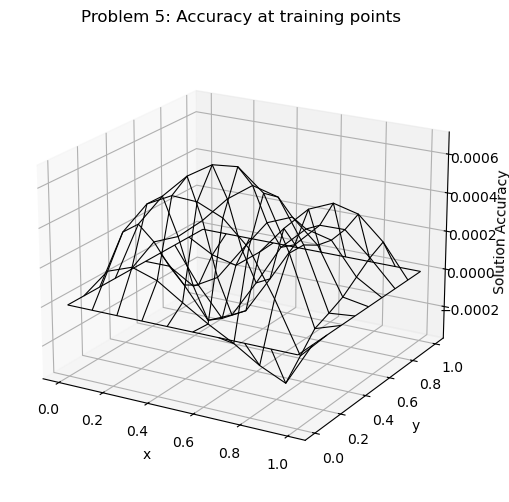

Problem 5: Accuracy at test points - max abs error: 6.937934e-04
Problem 5: Accuracy at test points - Z_trial shape: (30, 30)
Problem 5: Accuracy at test points - error shape: (30, 30)


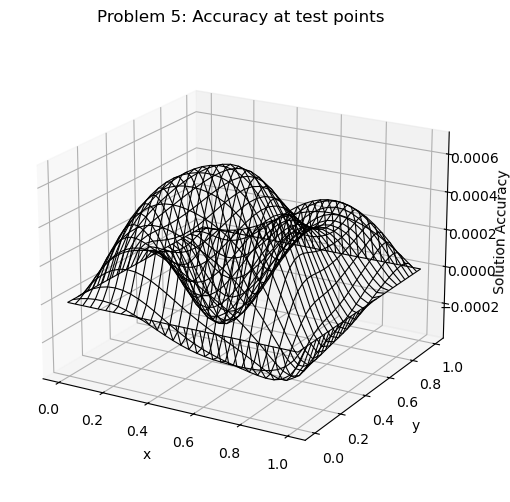

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt


# =========================
# 1. exact solution
# =========================
def exact_solution(x, y):
    return np.exp(-x) * (x + y**3)


# =========================
# 2. trial solution
# =========================
def trial_solution(inp, N):
    """
    inp: torch tensor of shape (num_points, 2)
    N  : trained neural network
    """
    x = inp[:, 0:1]   # shape (n,1)
    y = inp[:, 1:2]   # shape (n,1)

    exp_neg_1 = torch.exp(torch.tensor(-1.0, dtype=inp.dtype, device=inp.device))

    A = (1 - x) * y**3 \
        + x * (1 + y**3) * exp_neg_1 \
        + (1 - y) * x * (torch.exp(-x) - exp_neg_1) \
        + y * ((1 + x) * torch.exp(-x) - (1 - x + 2 * x * exp_neg_1))

    net_out = N(x, y)                  # should be (n,1)
    net_out = net_out.reshape(-1, 1)   # force column shape

    result = A + x * (1 - x) * y * (1 - y) * net_out
    return result                      # shape (n,1)


# =========================
# 3. plot helper
# =========================
def plot_error_wireframe(N, num_points, title):
    # grid
    x = np.linspace(0, 1, num_points)
    y = np.linspace(0, 1, num_points)
    X, Y = np.meshgrid(x, y)

    # exact solution
    Z_exact = exact_solution(X, Y)

    # neural solution
    xy_pairs = torch.tensor(
        np.column_stack([X.ravel(), Y.ravel()]),
        dtype=torch.float32
    )

    with torch.no_grad():
        Z_trial = trial_solution(xy_pairs, N).cpu().numpy().reshape(num_points, num_points)

    # error
    error = Z_trial - Z_exact

    print(f"{title} - max abs error: {np.max(np.abs(error)):.6e}")
    print(f"{title} - Z_trial shape: {Z_trial.shape}")
    print(f"{title} - error shape: {error.shape}")

    # plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_wireframe(X, Y, error, color='black', linewidth=0.8)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('Solution Accuracy')
    ax.set_title(title)

    # optional: make it look closer to the paper
    ax.view_init(elev=20, azim=-60)

    plt.show()


# =========================
# 4. reproduce Fig. 9 and Fig. 10
# =========================

# Fig. 9: training points = 10 x 10 = 100 points
plot_error_wireframe(N, num_points=10, title='Problem 5: Accuracy at training points')

# Fig. 10: test points = 30 x 30 = 900 points
plot_error_wireframe(N, num_points=30, title='Problem 5: Accuracy at test points')